# Importing Necessary Libraries

In [30]:
import os
import numpy as np
import random
import tensorflow as tf

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f"✅ Random seeds set to {SEED}")
print(f"✅ TensorFlow version: {tf.__version__}")
print(f"✅ NumPy version: {np.__version__}")


import cv2
from glob import glob
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import time
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from tensorflow.keras import layers, regularizers, optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras import backend as K





✅ Random seeds set to 42
✅ TensorFlow version: 2.18.1
✅ NumPy version: 2.0.1


# Loading Dataset and Train Test Split with some visualization

In [2]:
BASE_PATH = os.path.expanduser('~/Downloads/archive/')
IMAGES_PATH = os.path.join(BASE_PATH, 'Images')
LABELS_PATH = os.path.join(BASE_PATH, 'Masks')

IMG_HEIGHT, IMG_WIDTH = 512, 512
def load_data(image_dir, mask_dir, img_size=(512, 512)):
    valid_ext = ('.tif', '.tiff', '.png', '.jpg', '.jpeg')

    image_paths = sorted([
        p for p in glob(os.path.join(image_dir, '*')) if p.lower().endswith(valid_ext)
    ])
    mask_paths = sorted([
        p for p in glob(os.path.join(mask_dir, '*')) if p.lower().endswith(valid_ext)
    ])

    images, masks = [], []

    for img_path, mask_path in zip(image_paths, mask_paths):
        img = cv2.imread(img_path)
        if img is None:
            print(f"[WARNING] Could not load image: {img_path}")
            continue

        img = cv2.resize(img, img_size)
        img = img.astype(np.float32) / 255.0

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            print(f"[WARNING] Could not load mask: {mask_path}")
            continue

        mask = cv2.resize(mask, img_size)
        mask = np.expand_dims(mask, axis=-1)
        mask = (mask > 127).astype(np.float32)

        images.append(img)
        masks.append(mask)

    print(f"✅ Loaded {len(images)} images and {len(masks)} masks.")
    return np.array(images), np.array(masks)

X, Y = load_data(IMAGES_PATH, LABELS_PATH)
from sklearn.model_selection import train_test_split

train_size = 0.8
test_size = 1 - train_size

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, 
    train_size=train_size,
    test_size=test_size,
    random_state=42  
)

print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")

✅ Loaded 58 images and 58 masks.
X_train shape: (46, 512, 512, 3)
Y_train shape: (46, 512, 512, 1)
X_test shape: (12, 512, 512, 3)
Y_test shape: (12, 512, 512, 1)


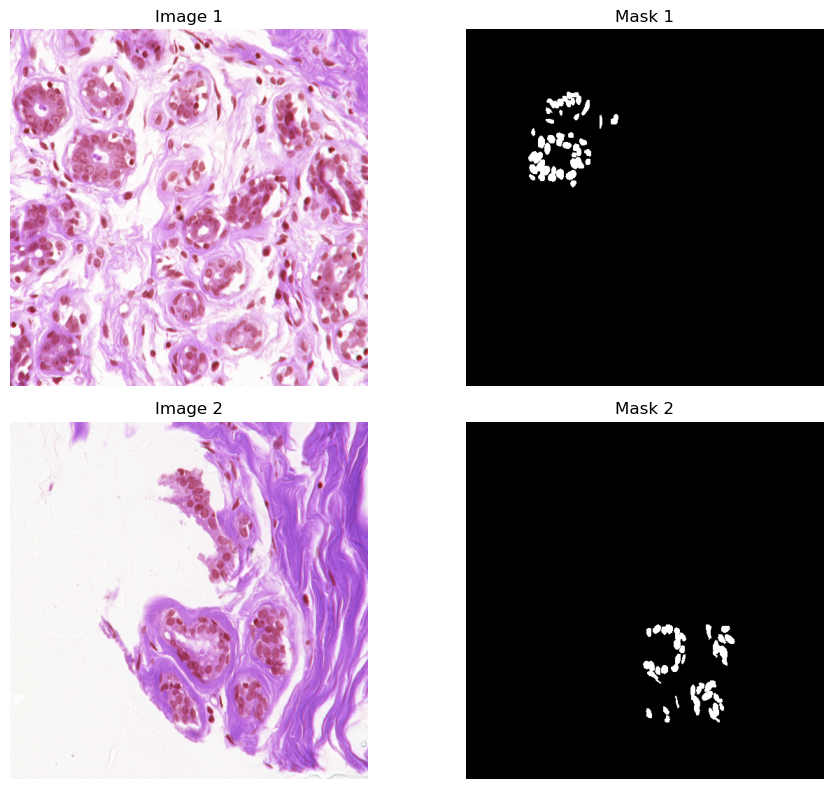

In [3]:
def visualize_samples(images, masks, num_samples=2):
    plt.figure(figsize=(10, 4 * num_samples))
    
    for i in range(num_samples):
        plt.subplot(num_samples, 2, 2*i + 1)
        plt.imshow(images[i])
        plt.title(f'Image {i+1}')
        plt.axis('off')

        plt.subplot(num_samples, 2, 2*i + 2)
        plt.imshow(masks[i].squeeze(), cmap='gray')
        plt.title(f'Mask {i+1}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()


visualize_samples(X, Y, num_samples=2)

# Creating Different Models

In [19]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def focal_loss(alpha=0.25, gamma=2.0):
    def focal_loss_fixed(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1 - K.epsilon())
        
        cross_entropy = -y_true * K.log(y_pred) - (1 - y_true) * K.log(1 - y_pred)
        
        weight = (alpha * y_true * K.pow(1 - y_pred, gamma) + 
                 (1 - alpha) * (1 - y_true) * K.pow(y_pred, gamma))
        
        loss = weight * cross_entropy
        return K.mean(loss)
    
    return focal_loss_fixed


def combined_dice_bce_loss(y_true, y_pred, dice_weight=0.5, bce_weight=0.5):
    dice = dice_loss(y_true, y_pred)
    
    y_pred_clipped = K.clip(y_pred, K.epsilon(), 1 - K.epsilon())
    bce = -K.mean(y_true * K.log(y_pred_clipped) + 
                  (1 - y_true) * K.log(1 - y_pred_clipped))
    
    return dice_weight * dice + bce_weight * bce

def weighted_bce_loss(pos_weight=10.0):

    def loss(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1 - K.epsilon())
        
        bce = -(pos_weight * y_true * K.log(y_pred) + 
                (1 - y_true) * K.log(1 - y_pred))
        
        return K.mean(bce)
    
    return loss


def plot_training_history(history):

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    metrics = [
        ('loss', 'Loss'),
        ('accuracy', 'Accuracy'),
        ('recall', 'Recall (Sensitivity)'),
        ('precision', 'Precision')
    ]
    
    for ax, (metric, title) in zip(axes.flat, metrics):
        ax.plot(history.history[metric], label=f'Training {title}')
        ax.plot(history.history[f'val_{metric}'], label=f'Validation {title}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.legend()
        ax.set_title(f'{title} over epochs')
        ax.grid(True)
    
    plt.tight_layout()
    plt.show()
    

    for metric, title in metrics:
        train_val = history.history[metric][-1]
        val_val = history.history[f'val_{metric}'][-1]
        print(f"{title:<20} {train_val:<15.4f} {val_val:<15.4f}")

In [20]:
def create_simple_CNN_model(input_shape, receptive_field, n_filters, 
                           n_layers, eta, lmbd,
                           activation='relu',
                           padding='same',
                           regularizer='l2',
                           optimizer_name='adam',
                           loss_function='bce'):

    model = Sequential()
    
    if regularizer == 'l2':
        reg = regularizers.l2(lmbd)
    elif regularizer == 'l1':
        reg = regularizers.l1(lmbd)
    elif regularizer == 'l1_l2':
        reg = regularizers.l1_l2(l1=lmbd, l2=lmbd)
    else:
        reg = None
    
    for i in range(n_layers):
        filters = n_filters * (2 ** i)
        
        if i == 0:
            model.add(layers.Conv2D(filters, (receptive_field, receptive_field), 
                                    input_shape=input_shape, padding=padding,
                                    activation=activation, 
                                    kernel_regularizer=reg))
        else:
            model.add(layers.Conv2D(filters, (receptive_field, receptive_field), 
                                    padding=padding, activation=activation, 
                                    kernel_regularizer=reg))
        
        model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    
    for i in range(n_layers - 1, -1, -1):
        filters = n_filters * (2 ** i)
        
        model.add(layers.Conv2DTranspose(filters, (receptive_field, receptive_field), 
                                         strides=(2, 2), padding=padding, 
                                         activation=activation))
    
    model.add(layers.Conv2D(1, (1, 1), activation='sigmoid'))

    if optimizer_name.lower() == 'adam':
        opt = optimizers.Adam(learning_rate=eta)
    elif optimizer_name.lower() == 'sgd':
        opt = optimizers.SGD(learning_rate=eta)
    elif optimizer_name.lower() == 'rmsprop':
        opt = optimizers.RMSprop(learning_rate=eta)
    else:
        opt = optimizers.Adam(learning_rate=eta)  # default
    
    if isinstance(loss_function, str):
        if loss_function in ['bce', 'binary_crossentropy']:
            loss = 'binary_crossentropy'
            metrics = ['accuracy',
                      tf.keras.metrics.Recall(name='recall'),
                      tf.keras.metrics.Precision(name='precision')]
        
        elif loss_function == 'dice':
            loss = dice_loss
            metrics = ['accuracy', dice_coefficient,
                      tf.keras.metrics.Recall(name='recall'),
                      tf.keras.metrics.Precision(name='precision')]
        
        elif loss_function == 'focal_high_recall':
            loss = focal_loss(alpha=0.75, gamma=2.0)
            metrics = ['accuracy',
                      tf.keras.metrics.Recall(name='recall'),
                      tf.keras.metrics.Precision(name='precision')]
        
        elif loss_function in ['combined', 'combined_dice_bce_loss']:  
            loss = combined_dice_bce_loss
            metrics = ['accuracy', dice_coefficient,
                      tf.keras.metrics.Recall(name='recall'),
                      tf.keras.metrics.Precision(name='precision')]
        
        elif loss_function == 'weighted_bce':
            loss = weighted_bce_loss(pos_weight=10.0) 
            metrics = ['accuracy',
                      tf.keras.metrics.Recall(name='recall'),
                      tf.keras.metrics.Precision(name='precision')]
        

    
    model.compile(loss=loss, optimizer=opt, metrics=metrics)
    
    return model

In [13]:
def create_unet_model(input_shape, receptive_field, n_filters, 
                      n_layers, eta, lmbd,
                      activation='relu',
                      padding='same',
                      regularizer='l2',
                      optimizer_name='adam',
                      loss_function='bce'):

    
    if regularizer == 'l2':
        reg = regularizers.l2(lmbd)
    elif regularizer == 'l1':
        reg = regularizers.l1(lmbd)
    elif regularizer == 'l1_l2':
        reg = regularizers.l1_l2(l1=lmbd, l2=lmbd)
    else:
        reg = None
    
    inputs = Input(shape=input_shape)
    
    skip_connections = []
    x = inputs
    
    for i in range(n_layers):
        filters = n_filters * (2 ** i)
        
        x = layers.Conv2D(filters, (receptive_field, receptive_field), 
                         padding=padding, activation=activation, 
                         kernel_regularizer=reg)(x)
        x = layers.Conv2D(filters, (receptive_field, receptive_field), 
                         padding=padding, activation=activation, 
                         kernel_regularizer=reg)(x)
        
        skip_connections.append(x)
        
        if i < n_layers - 1:
            x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    
    for i in range(n_layers - 2, -1, -1):
        filters = n_filters * (2 ** i)
        
        x = layers.Conv2DTranspose(filters, (receptive_field, receptive_field), 
                                   strides=(2, 2), padding=padding, 
                                   activation=activation)(x)
        
        x = layers.concatenate([x, skip_connections[i]])
        
        x = layers.Conv2D(filters, (receptive_field, receptive_field), 
                         padding=padding, activation=activation, 
                         kernel_regularizer=reg)(x)
        x = layers.Conv2D(filters, (receptive_field, receptive_field), 
                         padding=padding, activation=activation, 
                         kernel_regularizer=reg)(x)
    
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    
    if optimizer_name.lower() == 'adam':
        opt = optimizers.Adam(learning_rate=eta)
    elif optimizer_name.lower() == 'sgd':
        opt = optimizers.SGD(learning_rate=eta)
    elif optimizer_name.lower() == 'rmsprop':
        opt = optimizers.RMSprop(learning_rate=eta)
    else:
        opt = optimizers.Adam(learning_rate=eta)

    
    if isinstance(loss_function, str):
        if loss_function in ['bce', 'binary_crossentropy']:
            loss = 'binary_crossentropy'
            metrics = ['accuracy',
                      tf.keras.metrics.Recall(name='recall'),
                      tf.keras.metrics.Precision(name='precision')]
        
        elif loss_function == 'dice':
            loss = dice_loss
            metrics = ['accuracy', dice_coefficient,
                      tf.keras.metrics.Recall(name='recall'),
                      tf.keras.metrics.Precision(name='precision')]
        
        elif loss_function in ['combined', 'combined_dice_bce_loss']:  # ADD THIS CASE
            loss = combined_dice_bce_loss
            metrics = ['accuracy', dice_coefficient,
                      tf.keras.metrics.Recall(name='recall'),
                      tf.keras.metrics.Precision(name='precision')]
        
        elif loss_function == 'focal_high_recall':
            loss = focal_loss(alpha=0.75, gamma=2.0)
            metrics = ['accuracy',
                      tf.keras.metrics.Recall(name='recall'),
                      tf.keras.metrics.Precision(name='precision')]
        
        elif loss_function == 'weighted_bce':
            loss = weighted_bce_loss(pos_weight=10.0)  # Fixed at 10.0
            metrics = ['accuracy',
                      tf.keras.metrics.Recall(name='recall'),
                      tf.keras.metrics.Precision(name='precision')]
        
    
    model.compile(loss=loss, optimizer=opt, metrics=metrics)
    
    return model



In [14]:
def create_dense_segmentation_model(input_shape, n_hidden_layers, n_neurons, 
                                    eta, lmbd, activation='relu',
                                    regularizer='l2', optimizer_name='adam',
                                    loss_function='bce'):

    if regularizer == 'l2':
        reg = regularizers.l2(lmbd)
    elif regularizer == 'l1':
        reg = regularizers.l1(lmbd)
    elif regularizer == 'l1_l2':
        reg = regularizers.l1_l2(l1=lmbd, l2=lmbd)
    else:
        reg = None
    
    model = Sequential()
    
    model.add(layers.Flatten(input_shape=input_shape))
    
    for i in range(n_hidden_layers):
        model.add(layers.Dense(n_neurons, activation=activation, 
                              kernel_regularizer=reg))
    
    output_size = input_shape[0] * input_shape[1]
    model.add(layers.Dense(output_size, activation='sigmoid'))
    
    model.add(layers.Reshape((input_shape[0], input_shape[1], 1)))
    
    if optimizer_name.lower() == 'adam':
        opt = optimizers.Adam(learning_rate=eta)
    elif optimizer_name.lower() == 'sgd':
        opt = optimizers.SGD(learning_rate=eta)
    elif optimizer_name.lower() == 'rmsprop':
        opt = optimizers.RMSprop(learning_rate=eta)
    else:
        opt = optimizers.Adam(learning_rate=eta)
    
    if isinstance(loss_function, str):
        if loss_function in ['bce', 'binary_crossentropy']:
            loss = 'binary_crossentropy'
            metrics = ['accuracy',
                      tf.keras.metrics.Recall(name='recall'),
                      tf.keras.metrics.Precision(name='precision')]
        
        elif loss_function == 'dice':
            loss = dice_loss
            metrics = ['accuracy', dice_coefficient,
                      tf.keras.metrics.Recall(name='recall'),
                      tf.keras.metrics.Precision(name='precision')]
        
        elif loss_function in ['combined', 'combined_dice_bce_loss']:  # ADD THIS CASE
            loss = combined_dice_bce_loss
            metrics = ['accuracy', dice_coefficient,
                      tf.keras.metrics.Recall(name='recall'),
                      tf.keras.metrics.Precision(name='precision')]
        
        elif loss_function == 'focal_high_recall':
            loss = focal_loss(alpha=0.75, gamma=2.0)
            metrics = ['accuracy',
                      tf.keras.metrics.Recall(name='recall'),
                      tf.keras.metrics.Precision(name='precision')]
        
        elif loss_function == 'weighted_bce':
            loss = weighted_bce_loss(pos_weight=10.0)  # Fixed at 10.0
            metrics = ['accuracy',
                      tf.keras.metrics.Recall(name='recall'),
                      tf.keras.metrics.Precision(name='precision')]
        
    
    model.compile(loss=loss, optimizer=opt, metrics=metrics)
    
    return model




# Baseline Model and Finding Loss Function

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 512, 512, 16)   │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 256, 256, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 256, 256, 32)   │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 256, 256, 32)   │        50,208 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 512, 512, 16)   │        25,104 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 512, 512, 1)    │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,817 (401.63 KB)

 Trainable params: 102,817 (401.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


2025-12-18 00:15:33.135103: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-12-18 00:15:33.135378: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 827ms/step - accuracy: 0.6069 - loss: 0.6734 - precision: 0.0151 - recall: 0.3579

2025-12-18 00:15:38.753426: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-12-18 00:15:38.753684: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 944ms/step - accuracy: 0.6363 - loss: 0.6663 - precision: 0.0151 - recall: 0.3306 - val_accuracy: 0.9825 - val_loss: 0.2892 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 899ms/step - accuracy: 0.9836 - loss: 0.1842 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9825 - val_loss: 0.2021 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 890ms/step - accuracy: 0.9836 - loss: 0.1953 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9825 - val_loss: 0.1503 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 912ms/step - accuracy: 0.9836 - loss: 0.1172 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9825 - val_loss: 0.0985 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 931ms/step - accuracy: 0.9836 - loss: 0.0994 - precision: 0.0000e+00 - recall: 0.000

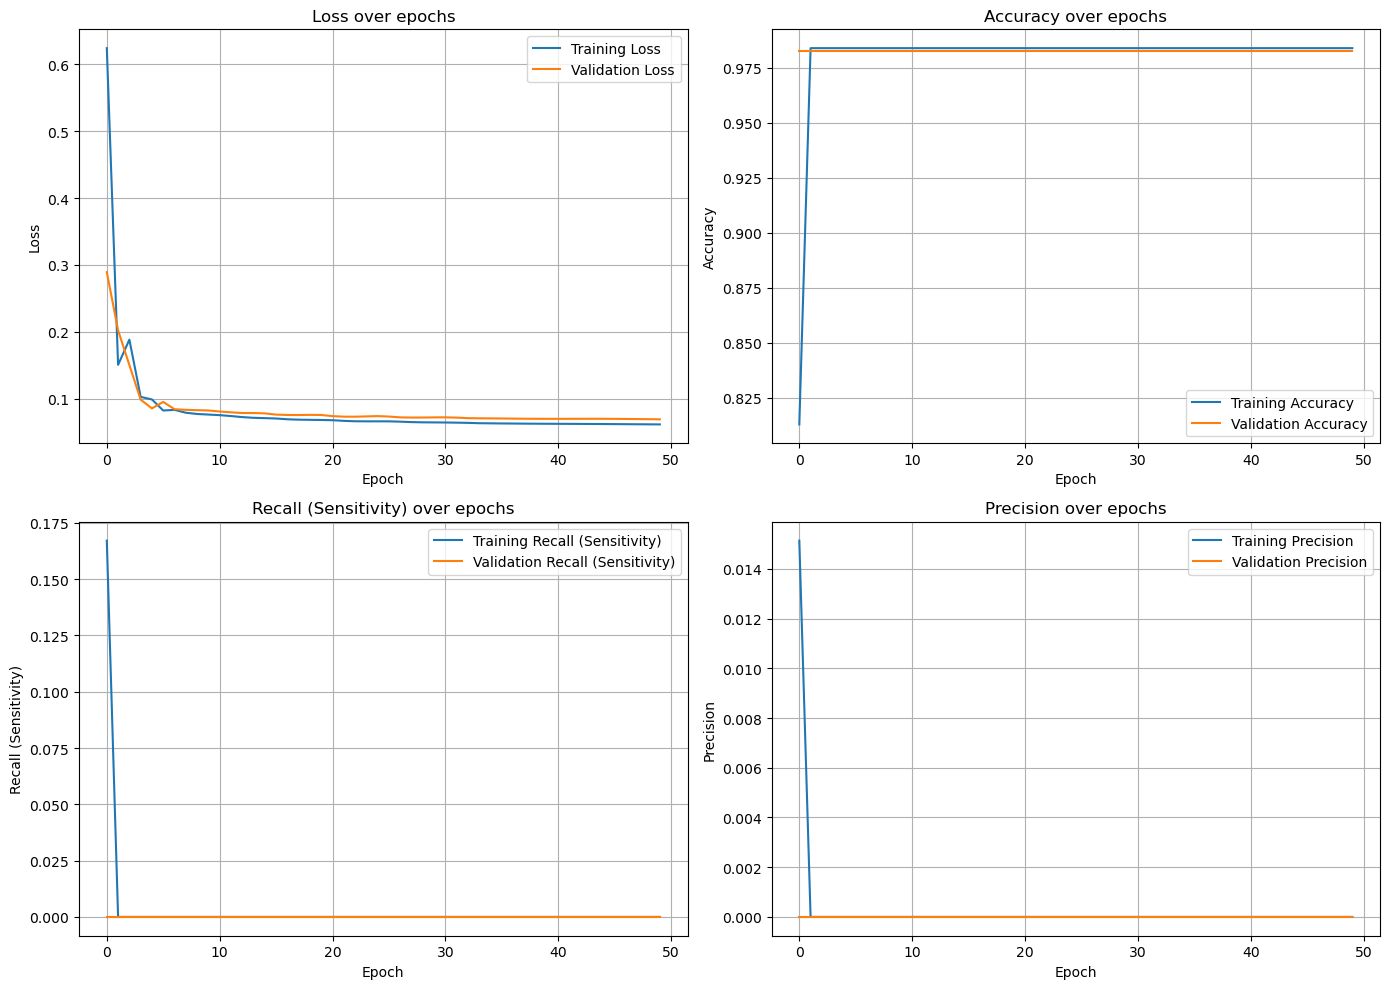

Loss                 0.0615          0.0691         
Accuracy             0.9840          0.9825         
Recall (Sensitivity) 0.0000          0.0000         
Precision            0.0000          0.0000         

Training completed!
Total time: 278.20 seconds (4.64 minutes)
Time per epoch: 5.56 seconds


In [32]:
start_time = time.time()

model = create_simple_CNN_model(
    input_shape=(512, 512, 3),
    receptive_field=7,
    n_filters=16,
    n_layers=2,
    eta=0.001,
    lmbd=0.0001,
    loss_function = 'bce'
)



model.summary()

epochs = 50
batch_size = 8

history = model.fit(
    X_train, Y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, Y_test),
    verbose=1
)



plot_training_history(history)

end_time = time.time()
training_time = end_time - start_time

# Print results
print(f"\n{'='*60}")
print(f"Training completed!")
print(f"Total time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
print(f"Time per epoch: {training_time/epochs:.2f} seconds")
print(f"{'='*60}")



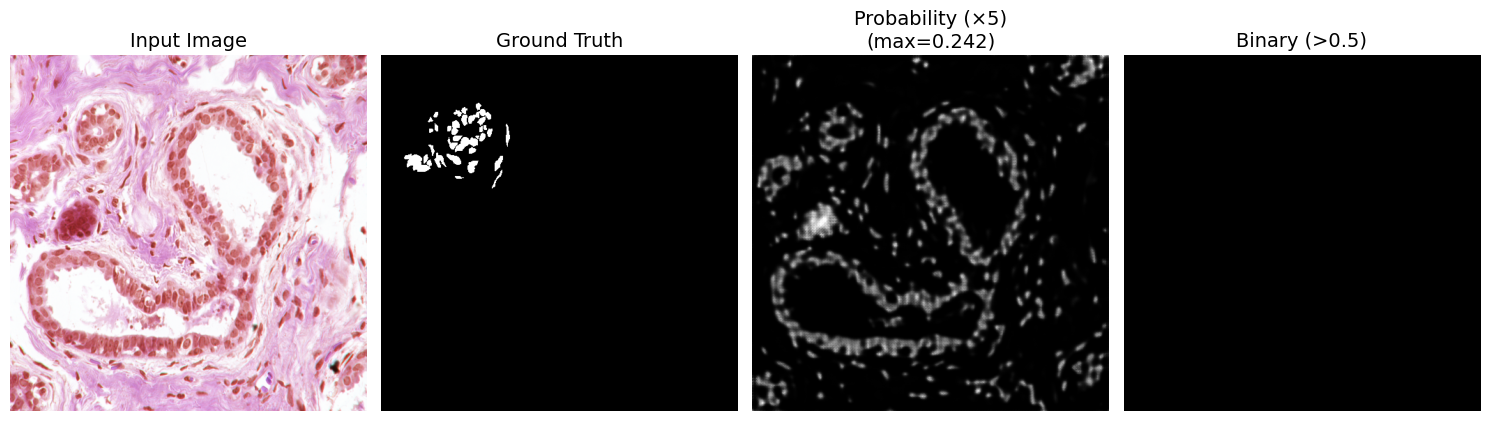

In [127]:
def plot_segmentation_results(model, X_test, Y_test, idx=None, threshold=0.5):

    predictions = model.predict(X_test, verbose=0)
    
    if idx is None:
        idx = np.random.choice(len(X_test))
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 4, 1)
    plt.imshow(X_test[idx])
    plt.axis('off')
    plt.title('Input Image', fontsize=14)
    
    plt.subplot(1, 4, 2)
    plt.imshow(Y_test[idx][:,:,0], cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
    plt.title('Ground Truth', fontsize=14)
    
    plt.subplot(1, 4, 3)
    pred_img = predictions[idx][:,:,0]
    pred_amplified = np.clip(pred_img * 5.0, 0, 1)  
    plt.imshow(pred_amplified, cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
    plt.title(f'Probability (×5)\n(max={predictions[idx].max():.3f})', fontsize=14)
    
    binary_pred = (predictions[idx][:,:,0] > threshold).astype(float)
    plt.subplot(1, 4, 4)
    plt.imshow(binary_pred, cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
    plt.title(f'Binary (>{threshold})', fontsize=14)
    
    plt.tight_layout()
    plt.show()

plot_segmentation_results(model, X_test, Y_test, idx=5)  


model is just learning to classify everything as 0 which leads to a high accuracy score, but recall score = 0. this is due to severe class imbalance so we need to find a loss function that gives higher weights to positives

Training with: bce


/opt/anaconda3/envs/datascience/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final Validation Loss: 0.0718
Final Validation Recall: 0.0000
Final Validation Precision: 0.0000
Final Validation Accuracy: 0.9825
Max Prediction: 0.3280
Predictions > 0.5: 0
Training with: dice
Final Validation Loss: 0.8277
Final Validation Recall: 0.3893
Final Validation Precision: 0.1092
Final Validation Accuracy: 0.9339
Max Prediction: 1.0000
Predictions > 0.5: 195846
Training with: focal_high_recall
Final Validation Loss: 0.0104
Final Validation Recall: 0.0000
Final Validation Precision: 0.0000
Final Validation Accuracy: 0.9825
Max Prediction: 0.4584
Predictions > 0.5: 0
Training with: weighted_bce
Final Validation Loss: 0.3138
Final Validation Recall: 0.3906
Final Validation Precision: 0.1106
Final Validation Accuracy: 0.9345
Max Prediction: 0.7578
Predictions > 0.5: 193881
Training with: combined_dice_bce_loss
Final Validation Loss: 0.4769
Final Validation Recall: 0.1532
Final Validation Precision: 0.1264
Final Validation Accuracy: 0.9667
Max Prediction: 0.8824
Predictions > 0.5

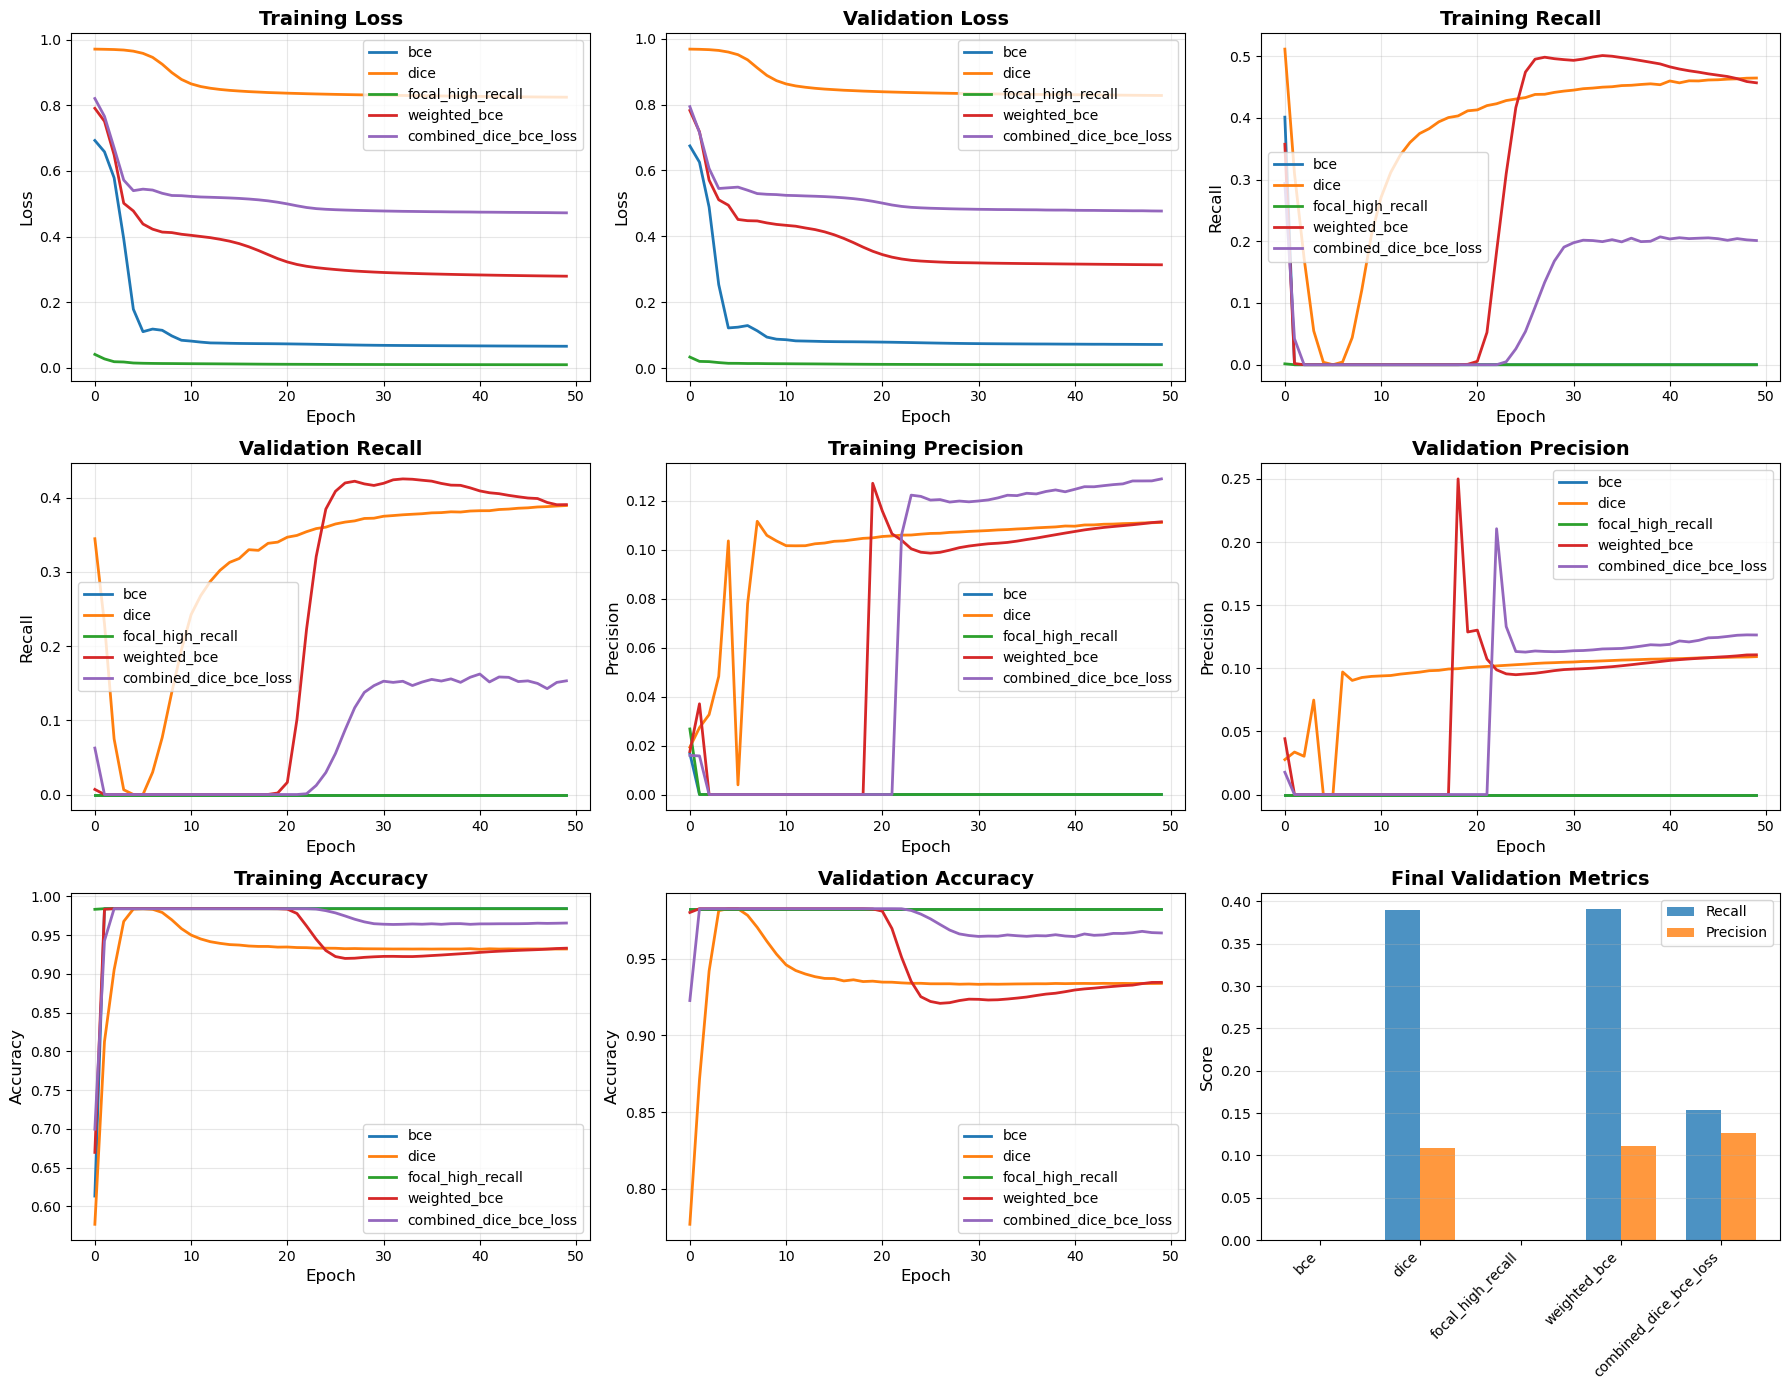

SUMMARY TABLE (Sorted by Validation Recall)
         Loss Function  Val Loss  Val Recall  Val Precision  Val Accuracy  Max Pred  Mean Pred  Preds > 0.5
          weighted_bce  0.313768    0.390605       0.110645      0.934547  0.757833   0.101602       193881
                  dice  0.827687    0.389348       0.109183      0.933879  1.000000   0.063305       195846
combined_dice_bce_loss  0.476931    0.153168       0.126371      0.966729  0.882359   0.032132        66566
                   bce  0.071844    0.000000       0.000000      0.982541  0.327995   0.015296            0
     focal_high_recall  0.010405    0.000000       0.000000      0.982541  0.458438   0.160563            0


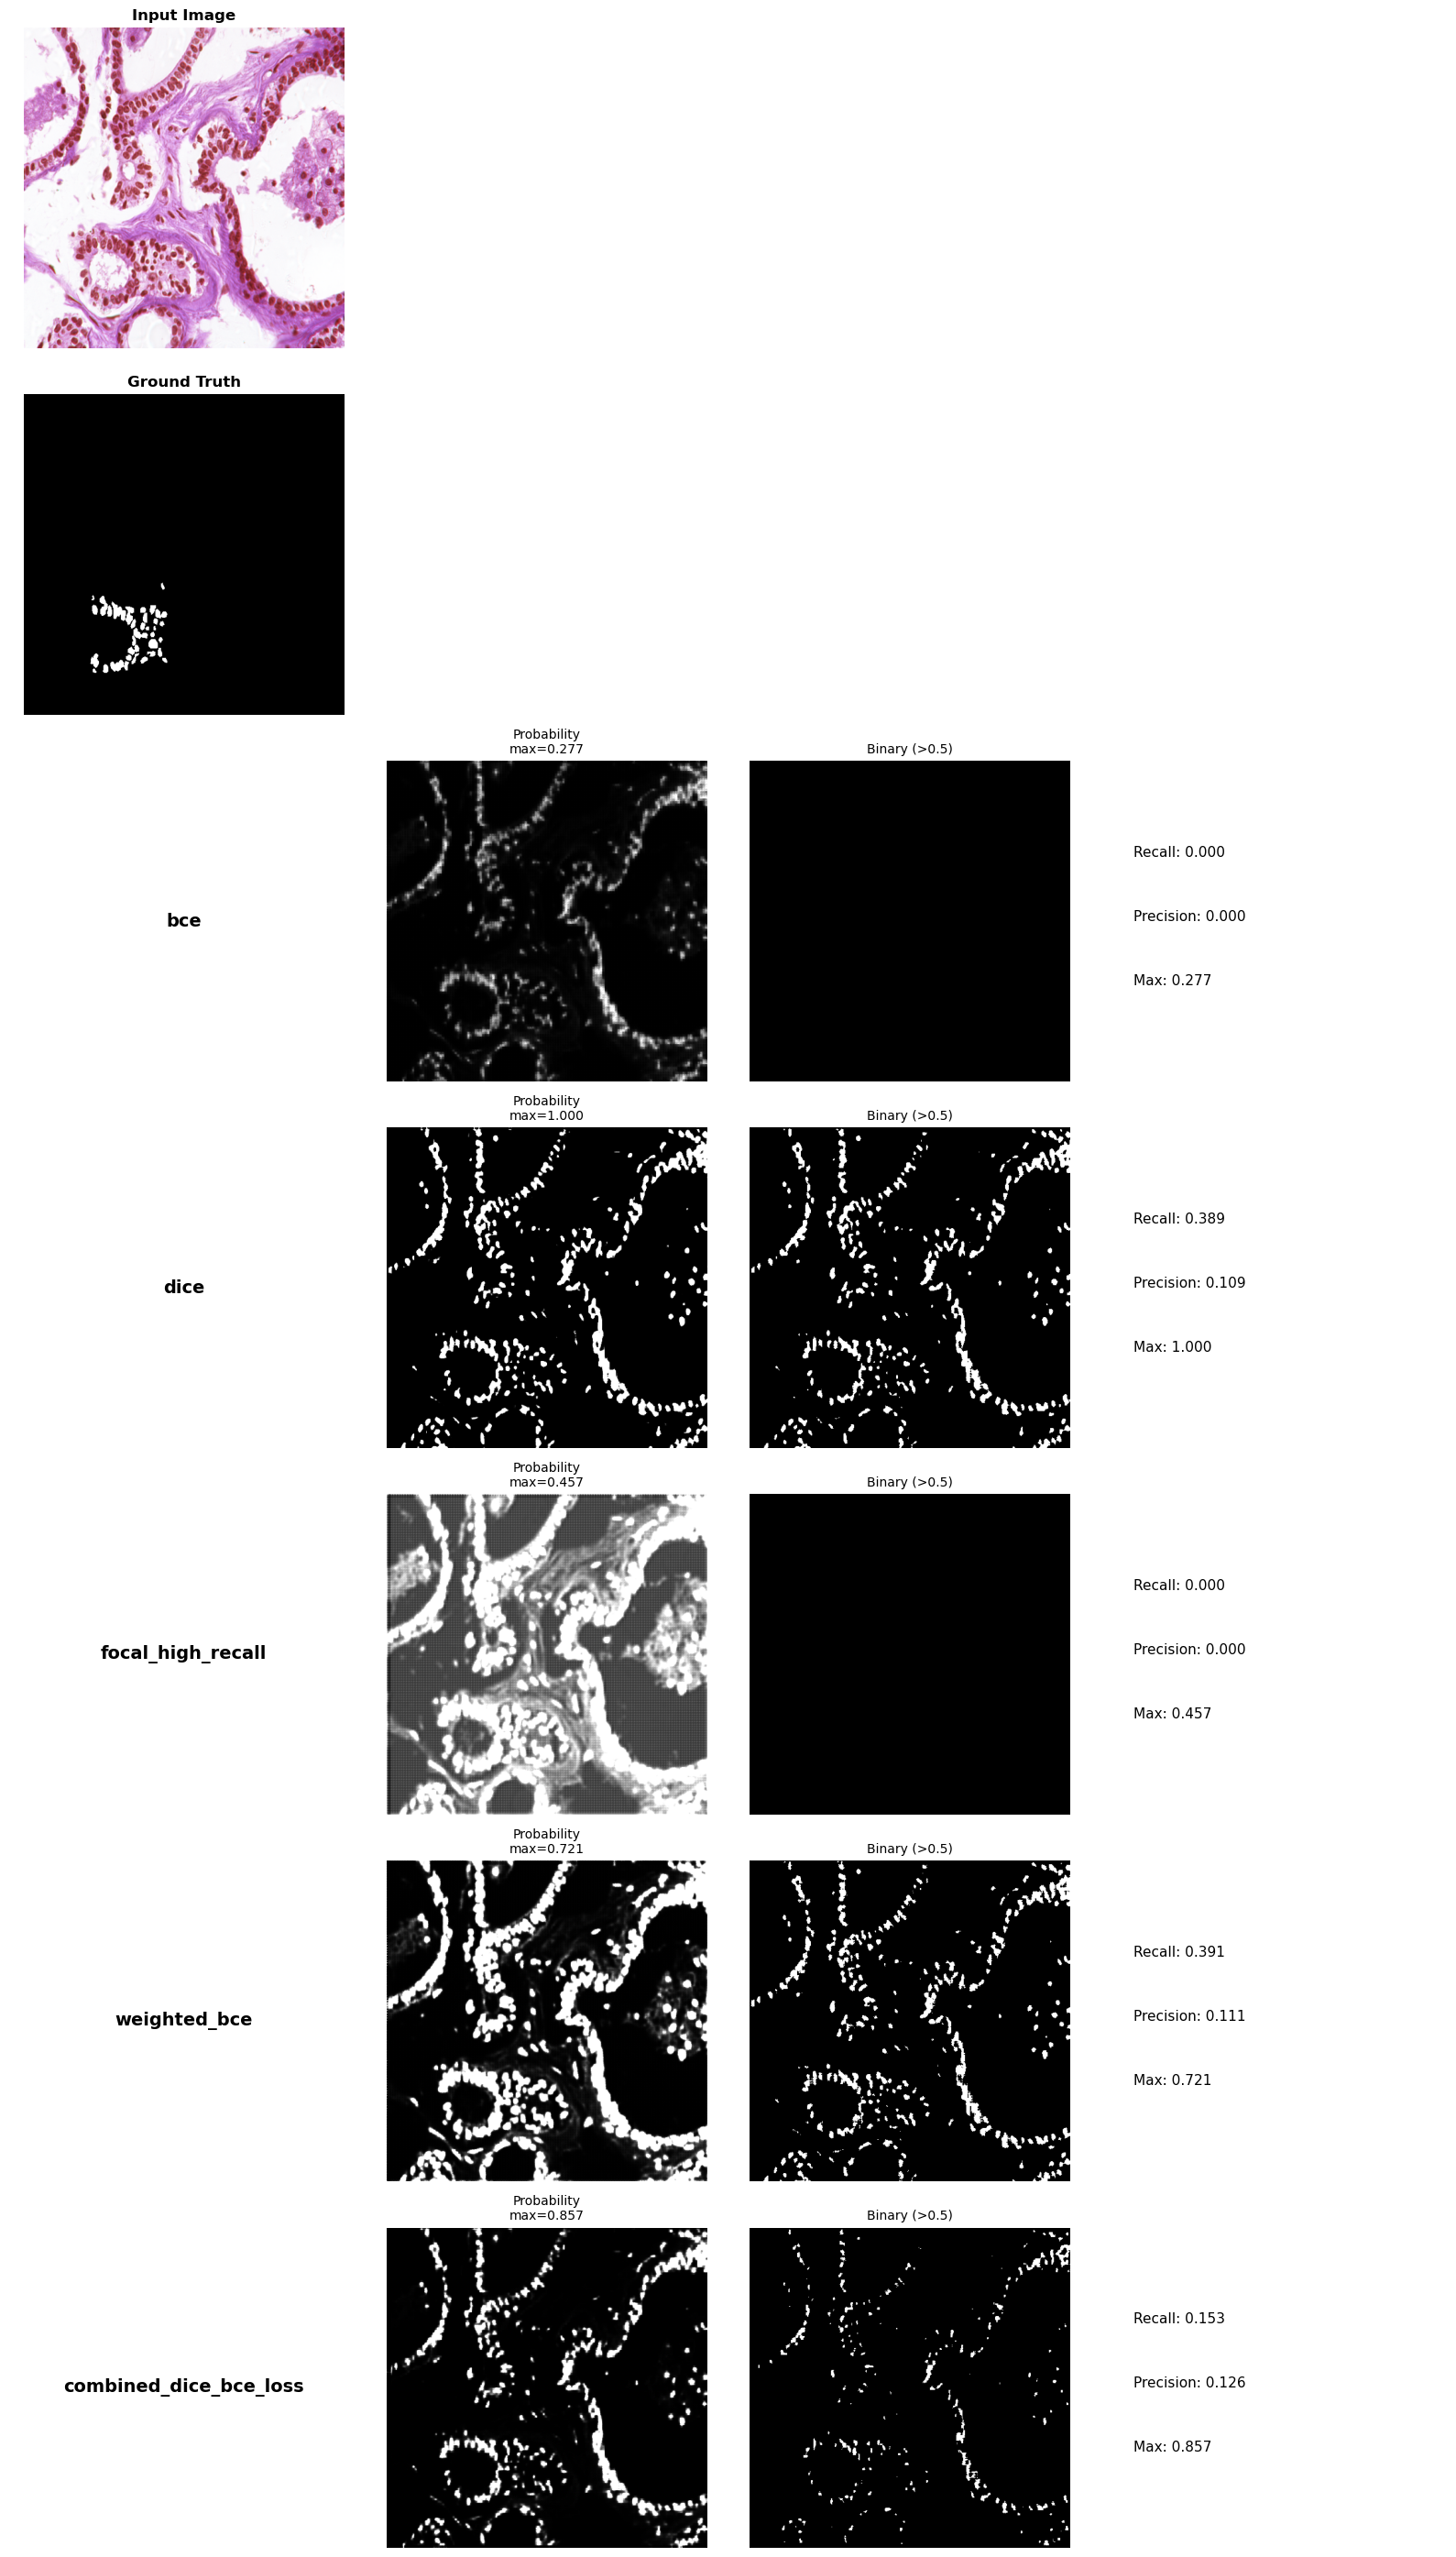

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def compare_loss_functions(input_shape, receptive_field, n_filters, n_layers, 
                          eta, lmbd, epochs=50, batch_size=8):

    
    loss_functions = ['bce', 'dice', 'focal_high_recall', 'weighted_bce', 'combined_dice_bce_loss']
    
    results = {}
    

    for loss_name in loss_functions:
        print(f"Training with: {loss_name}")
        
        model = create_simple_CNN_model(
            input_shape=input_shape,
            receptive_field=receptive_field,
            n_filters=n_filters,
            n_layers=n_layers,
            eta=eta,
            lmbd=lmbd,
            loss_function=loss_name
        )
        
        history = model.fit(
            X_train, Y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(X_test, Y_test),
            verbose=0  
        )
        
        predictions = model.predict(X_test, verbose=0)
        
        # Store results
        results[loss_name] = {
            'model': model,
            'history': history,
            'predictions': predictions,
            'final_val_loss': history.history['val_loss'][-1],
            'final_val_recall': history.history['val_recall'][-1],
            'final_val_precision': history.history['val_precision'][-1],
            'final_val_accuracy': history.history['val_accuracy'][-1],
            'max_prediction': predictions.max(),
            'mean_prediction': predictions.mean(),
            'preds_above_05': (predictions > 0.5).sum()
        }
        
        print(f"Final Validation Loss: {results[loss_name]['final_val_loss']:.4f}")
        print(f"Final Validation Recall: {results[loss_name]['final_val_recall']:.4f}")
        print(f"Final Validation Precision: {results[loss_name]['final_val_precision']:.4f}")
        print(f"Final Validation Accuracy: {results[loss_name]['final_val_accuracy']:.4f}")
        print(f"Max Prediction: {results[loss_name]['max_prediction']:.4f}")
        print(f"Predictions > 0.5: {results[loss_name]['preds_above_05']}")
    
    return results


def plot_comparison(results):
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    
    ax = axes[0, 0]
    for name, result in results.items():
        ax.plot(result['history'].history['loss'], label=name, linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Training Loss', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax = axes[0, 1]
    for name, result in results.items():
        ax.plot(result['history'].history['val_loss'], label=name, linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Validation Loss', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax = axes[0, 2]
    for name, result in results.items():
        ax.plot(result['history'].history['recall'], label=name, linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Recall', fontsize=12)
    ax.set_title('Training Recall', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax = axes[1, 0]
    for name, result in results.items():
        ax.plot(result['history'].history['val_recall'], label=name, linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Recall', fontsize=12)
    ax.set_title('Validation Recall', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax = axes[1, 1]
    for name, result in results.items():
        ax.plot(result['history'].history['precision'], label=name, linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title('Training Precision', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax = axes[1, 2]
    for name, result in results.items():
        ax.plot(result['history'].history['val_precision'], label=name, linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title('Validation Precision', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax = axes[2, 0]
    for name, result in results.items():
        ax.plot(result['history'].history['accuracy'], label=name, linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Training Accuracy', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax = axes[2, 1]
    for name, result in results.items():
        ax.plot(result['history'].history['val_accuracy'], label=name, linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Validation Accuracy', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    ax = axes[2, 2]
    loss_names = list(results.keys())
    final_recalls = [results[name]['final_val_recall'] for name in loss_names]
    final_precisions = [results[name]['final_val_precision'] for name in loss_names]
    
    x = np.arange(len(loss_names))
    width = 0.35
    
    ax.bar(x - width/2, final_recalls, width, label='Recall', alpha=0.8)
    ax.bar(x + width/2, final_precisions, width, label='Precision', alpha=0.8)
    
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Final Validation Metrics', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(loss_names, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()


def create_summary_table(results):
 
    summary_data = []
    
    for name, result in results.items():
        summary_data.append({
            'Loss Function': name,
            'Val Loss': result['final_val_loss'],
            'Val Recall': result['final_val_recall'],
            'Val Precision': result['final_val_precision'],
            'Val Accuracy': result['final_val_accuracy'],
            'Max Pred': result['max_prediction'],
            'Mean Pred': result['mean_prediction'],
            'Preds > 0.5': result['preds_above_05']
        })
    
    df = pd.DataFrame(summary_data)
    
    # Sort by validation recall (most important for cancer detection)
    df = df.sort_values('Val Recall', ascending=False)
    
    print("SUMMARY TABLE (Sorted by Validation Recall)")
    print(df.to_string(index=False))
    
    return df


def visualize_predictions(results, X_test, Y_test, idx=None):

    if idx is None:
        idx = np.random.choice(len(X_test))
    
    n_losses = len(results)
    fig, axes = plt.subplots(n_losses + 2, 4, figsize=(16, 4 * (n_losses + 2)))
    
    axes[0, 0].imshow(X_test[idx])
    axes[0, 0].axis('off')
    axes[0, 0].set_title('Input Image', fontsize=12, fontweight='bold')
    
    for col in range(1, 4):
        axes[0, col].axis('off')
    
    axes[1, 0].imshow(Y_test[idx][:,:,0], cmap='gray')
    axes[1, 0].axis('off')
    axes[1, 0].set_title('Ground Truth', fontsize=12, fontweight='bold')
    
    for col in range(1, 4):
        axes[1, col].axis('off')
    
    for row, (name, result) in enumerate(results.items(), start=2):
        pred = result['predictions'][idx][:,:,0]
        
        axes[row, 0].text(0.5, 0.5, name, ha='center', va='center', 
                         fontsize=14, fontweight='bold')
        axes[row, 0].axis('off')
        
        pred_amplified = np.clip(pred * 5.0, 0, 1)
        axes[row, 1].imshow(pred_amplified, cmap='gray', vmin=0, vmax=1)
        axes[row, 1].axis('off')
        axes[row, 1].set_title(f'Probability\nmax={pred.max():.3f}', fontsize=10)
        
        binary = (pred > 0.5).astype(float)
        axes[row, 2].imshow(binary, cmap='gray')
        axes[row, 2].axis('off')
        axes[row, 2].set_title('Binary (>0.5)', fontsize=10)
        
        recall = result['final_val_recall']
        precision = result['final_val_precision']
        axes[row, 3].text(0.1, 0.7, f'Recall: {recall:.3f}', fontsize=11)
        axes[row, 3].text(0.1, 0.5, f'Precision: {precision:.3f}', fontsize=11)
        axes[row, 3].text(0.1, 0.3, f'Max: {pred.max():.3f}', fontsize=11)
        axes[row, 3].axis('off')
    
    plt.tight_layout()
    plt.show()


# Run the complete comparison
results = compare_loss_functions(
    input_shape=(512, 512, 3),
    receptive_field=3,
    n_filters=16,
    n_layers=2,
    eta=0.001,
    lmbd=0.0001,
    epochs=50,
    batch_size=8
)

# Plot comparisons
plot_comparison(results)

# Create summary table
summary_df = create_summary_table(results)

# Visualize predictions on same image
visualize_predictions(results, X_test, Y_test)

# Motivation for CNN by comparing with Dense fully connected Network

Model: "sequential_49"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 786432)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 512)            │   402,653,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 262144)         │   134,479,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_9 (Reshape)             │ (None, 512, 512, 1)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 537,396,224 (2.00 GB)

 Trainable params: 537,396,224 (2.00 GB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6983 - loss: 1.1388 - precision: 0.0194 - recall: 0.3368 - val_accuracy: 0.9420 - val_loss: 0.6613 - val_precision: 0.0339 - val_recall: 0.0845
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9358 - loss: 0.6870 - precision: 0.0554 - recall: 0.1854 - val_accuracy: 0.9535 - val_loss: 1.7921 - val_precision: 0.0430 - val_recall: 0.0783
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 984ms/step - accuracy: 0.9395 - loss: 1.7515 - precision: 0.0489 - recall: 0.1431 - val_accuracy: 0.9000 - val_loss: 2.7528 - val_precision: 0.0306 - val_recall: 0.1540
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9156 - loss: 2.3794 - precision: 0.0386 - recall: 0.1731 - val_accuracy: 0.8687 - val_loss: 3.7392 - val_precision: 0.0284 - val_recall: 0.1965
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 862ms/step - accuracy: 0.8894 - loss: 3.5278 - precision: 0.0301 - recall: 0.1837 - val_accuracy: 0.9211 - val_loss: 3.8122 - val_precisi

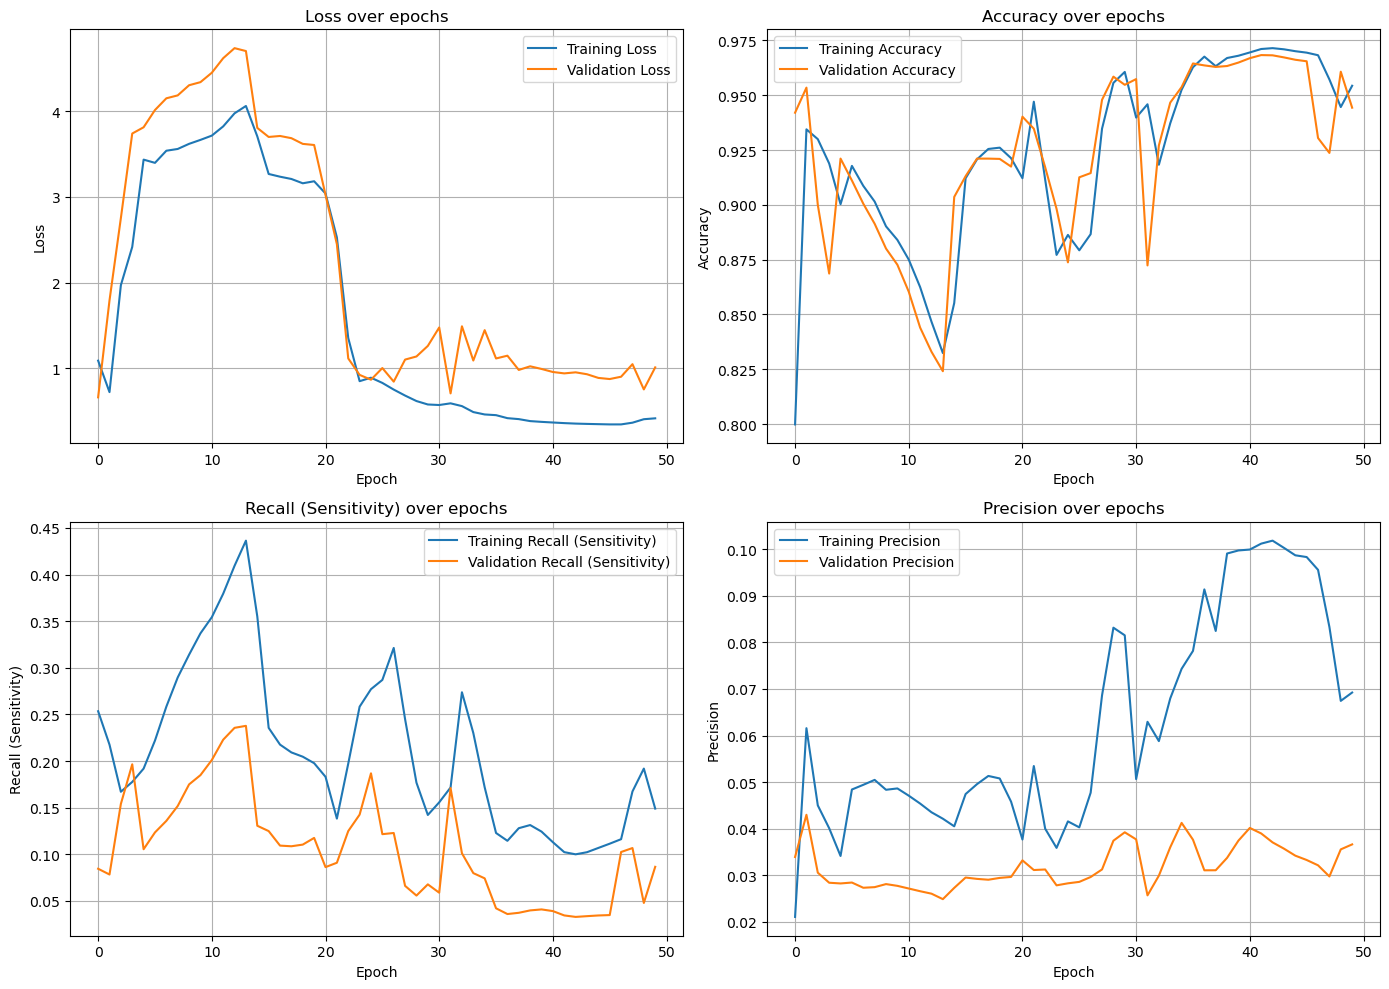

Loss                 0.4166          1.0111         
Accuracy             0.9544          0.9443         
Recall (Sensitivity) 0.1490          0.0865         
Precision            0.0692          0.0366         
Total time: 288.65 seconds (4.81 minutes)
Time per epoch: 5.77 seconds


In [140]:
start_time = time.time()

dense_model = create_dense_segmentation_model(
    input_shape=(512, 512, 3),
    n_hidden_layers=2,
    n_neurons=512,
    eta=0.001,
    lmbd=0.0001,
    loss_function='weighted_bce'
)

dense_model.summary()

epochs = 50
batch_size = 8

history = dense_model.fit(
    X_train, Y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, Y_test),
    verbose=1
)


plot_training_history(history)

end_time = time.time()
training_time = end_time - start_time


print(f"Total time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
print(f"Time per epoch: {training_time/epochs:.2f} seconds")

/opt/anaconda3/envs/datascience/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_180 (Conv2D)             │ (None, 512, 512, 16)   │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_92 (MaxPooling2D) │ (None, 256, 256, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_181 (Conv2D)             │ (None, 256, 256, 32)   │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_93 (MaxPooling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_92             │ (None, 256, 256, 32)   │        50,208 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_93             │ (None, 512, 512, 16)   │        25,104 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_182 (Conv2D)             │ (None, 512, 512, 1)    │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,817 (401.63 KB)

 Trainable params: 102,817 (401.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 969ms/step - accuracy: 0.8321 - loss: 0.7134 - precision: 0.0142 - recall: 0.1373 - val_accuracy: 0.9825 - val_loss: 0.5972 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 949ms/step - accuracy: 0.9836 - loss: 0.5148 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9825 - val_loss: 0.4890 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 943ms/step - accuracy: 0.9836 - loss: 0.4522 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9825 - val_loss: 0.4809 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 936ms/step - accuracy: 0.9836 - loss: 0.4445 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9825 - val_loss: 0.4531 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 938ms/step - accuracy: 0.9836 - loss: 0.4239 - precision: 0.0000e+00 - re

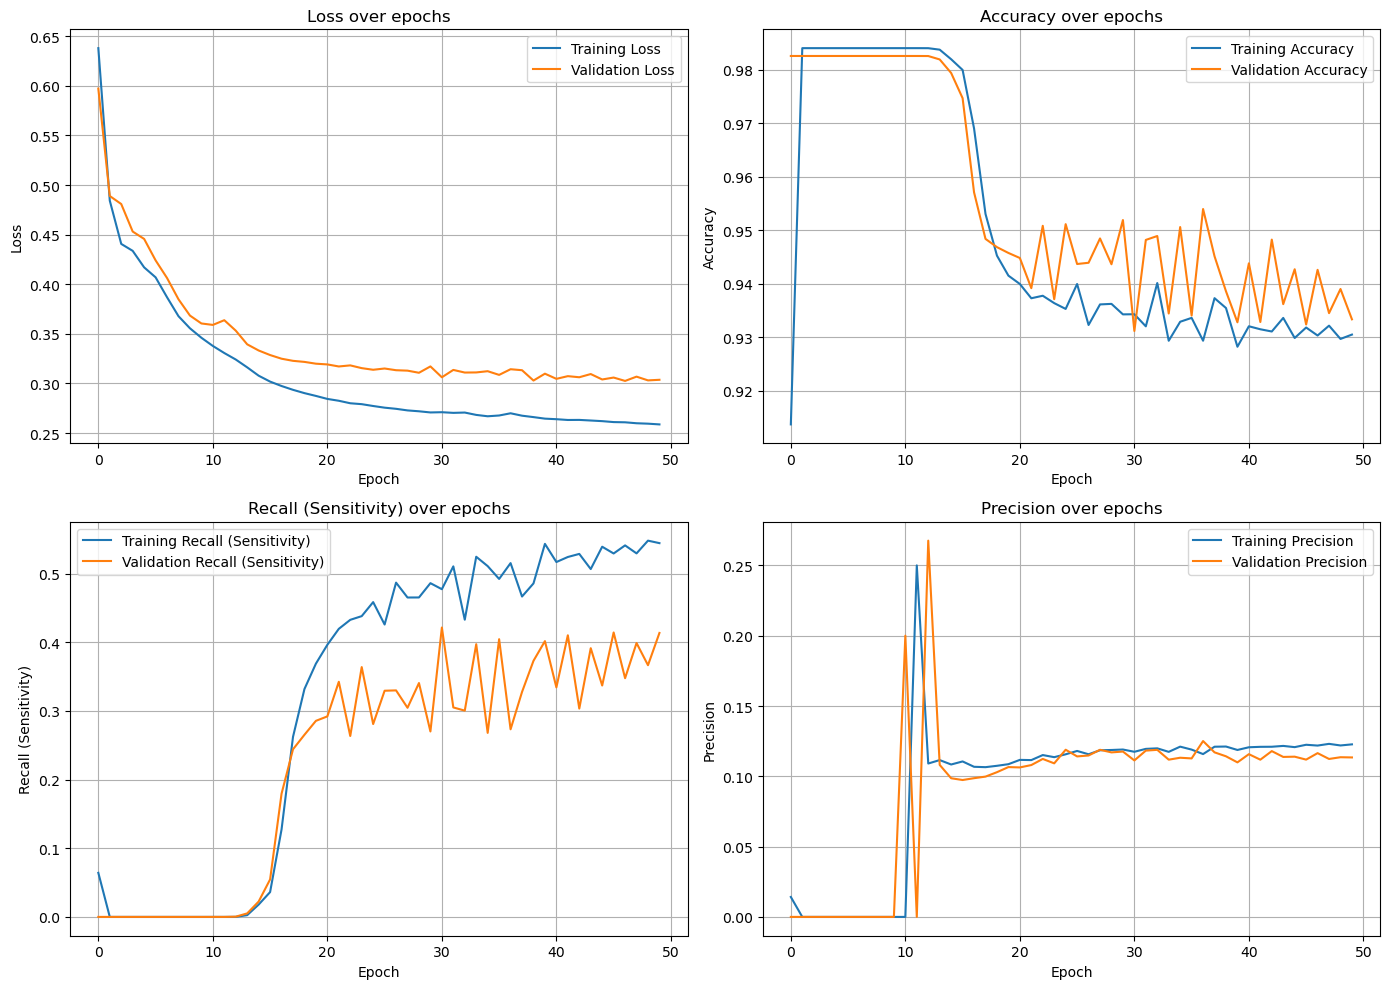

Loss                 0.2587          0.3037         
Accuracy             0.9305          0.9333         
Recall (Sensitivity) 0.5442          0.4135         
Precision            0.1227          0.1134         

Training completed!
Total time: 281.18 seconds (4.69 minutes)
Time per epoch: 5.62 seconds


In [141]:
start_time = time.time()

model = create_simple_CNN_model(
    input_shape=(512, 512, 3),
    receptive_field=7,
    n_filters=16,
    n_layers=2,
    eta=0.001,
    lmbd=0.0001,
    loss_function = 'weighted_bce'
)



model.summary()

epochs = 50
batch_size = 8

history = model.fit(
    X_train, Y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, Y_test),
    verbose=1
)



plot_training_history(history)

end_time = time.time()
training_time = end_time - start_time

# Print results
print(f"\n{'='*60}")
print(f"Training completed!")
print(f"Total time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
print(f"Time per epoch: {training_time/epochs:.2f} seconds")
print(f"{'='*60}")



# Future Codes

Model: "functional_341"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_55      │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_183 (Conv2D) │ (None, 512, 512,  │        448 │ input_layer_55[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_184 (Conv2D) │ (None, 512, 512,  │      2,320 │ conv2d_183[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_94    │ (None, 256, 256,  │          0 │ conv2d_184[0][0]  │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_185 (Conv2D) │ (None, 256, 256,  │      4,640 │ max_pooling2d_94… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_186 (Conv2D) │ (None, 256, 256,  │      9,248 │ conv2d_185[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_95    │ (None, 128, 128,  │          0 │ conv2d_186[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_187 (Conv2D) │ (None, 128, 128,  │     18,496 │ max_pooling2d_95… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_188 (Conv2D) │ (None, 128, 128,  │     36,928 │ conv2d_187[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_96    │ (None, 64, 64,    │          0 │ conv2d_188[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_189 (Conv2D) │ (None, 64, 64,    │     73,856 │ max_pooling2d_96… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_190 (Conv2D) │ (None, 64, 64,    │    147,584 │ conv2d_189[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_94 │ (None, 128, 128,  │     73,792 │ conv2d_190[0][0]  │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_12      │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_188[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_191 (Conv2D) │ (None, 128, 128,  │     73,792 │ concatenate_12[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_192 (Conv2D) │ (None, 128, 128,  │     36,928 │ conv2d_191[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_95 │ (None, 256, 256,  │     18,464 │ conv2d_192[0][0]

 Total params: 535,793 (2.04 MB)

 Trainable params: 535,793 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9607 - loss: 0.8013 - precision: 0.0385 - recall: 0.0595 - val_accuracy: 0.9825 - val_loss: 0.6295 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9836 - loss: 0.5423 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9825 - val_loss: 0.5032 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9836 - loss: 0.4556 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9825 - val_loss: 0.4422 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9836 - loss: 0.4041 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9825 - val_loss: 0.4252 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9836 - loss: 0.3898 - precision: 0.0000e+00 - recall: 0.0000e+

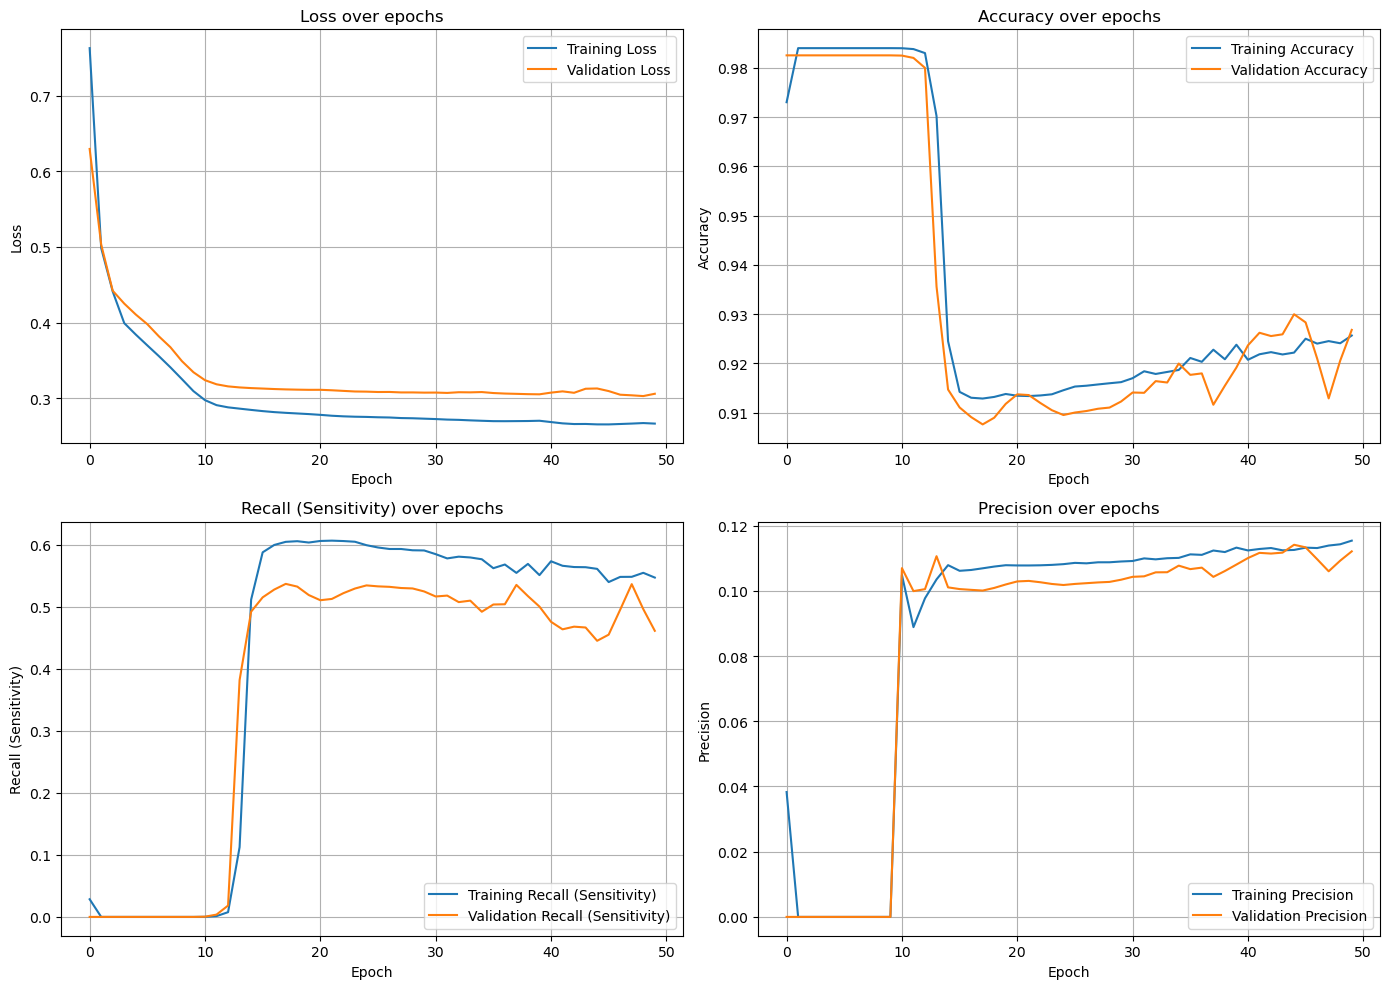

Loss                 0.2667          0.3061         
Accuracy             0.9256          0.9268         
Recall (Sensitivity) 0.5472          0.4614         
Precision            0.1154          0.1121         


In [142]:
# Example Usage of UNET For later parts
model = create_unet_model(
    input_shape=(512, 512, 3),
    receptive_field=3,
    n_filters=16,
    n_layers=4,
    eta=0.001,
    lmbd=0.0001,
    loss_function='weighted_bce'
)
model.summary()

epochs = 50
batch_size = 8

history = model.fit(
    X_train, Y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, Y_test),
    verbose=1
)


plot_training_history(history)

In [ ]:
# Usage with custom parameters
model = create_simple_CNN_model(
    input_shape=(512, 512, 3),
    receptive_field=3,
    n_filters=64,
    n_layers=2,
    eta=0.001,
    lmbd=0.001,
    activation='relu',           # Can be 'relu', 'elu', 'leaky_relu', 'tanh', etc.         
    regularizer='l1',           # 'l1', 'l2', 'l1_l2', or None
    optimizer_name='rmsprop',    # 'adam', 'sgd', 'rmsprop'
    loss_function= "weighted_bce"
)

model.summary()

epochs = 50
batch_size = 8

history = model.fit(
    X_train, Y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, Y_test),
    verbose=1
)


plot_training_history(history)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 512, 512, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 256, 256, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 256, 256, 128)  │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 512, 512, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 512, 512, 1)    │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 297,089 (1.13 MB)

 Trainable params: 297,089 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


2025-12-18 00:20:28.134650: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-12-18 00:20:28.134947: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7970 - loss: 2.8000 - precision: 0.0154 - recall: 0.1838

2025-12-18 00:20:35.574797: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-12-18 00:20:35.575041: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8124 - loss: 2.7669 - precision: 0.0154 - recall: 0.1688 - val_accuracy: 0.9825 - val_loss: 2.1121 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9836 - loss: 1.9635 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9825 - val_loss: 1.6961 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9836 - loss: 1.5821 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9825 - val_loss: 1.3955 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9836 - loss: 1.2938 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9825 - val_loss: 1.1503 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9836 - loss: 1.0591 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_acc